In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
column_names = [
    'status_konta', 'czas_trwania_msc', 'historia_kredytowa', 'cel_kredytu',
    'kwota_kredytu', 'stan_oszczednosci', 'zatrudnienie_od',
    'raty_proc_dochodu', 'stan_cywilny_plec', 'inni_dluznicy',
    'lata_w_miejscu_zamieszkania', 'majatek', 'wiek',
    'inne_raty', 'mieszkanie', 'liczba_kredytow_w_banku',
    'zawod', 'liczba_osob_na_utrzymaniu', 'telefon', 'pracownik_zagraniczny',
    'target'
]

df = pd.read_csv('../data/raw/german_credit/german.data', sep=' ', header=None, names=column_names)

df.head()

,status_konta,czas_trwania_msc,historia_kredytowa,cel_kredytu,kwota_kredytu,stan_oszczednosci,zatrudnienie_od,raty_proc_dochodu,stan_cywilny_plec,inni_dluznicy,lata_w_miejscu_zamieszkania,majatek,wiek,inne_raty,mieszkanie,liczba_kredytow_w_banku,zawod,liczba_osob_na_utrzymaniu,telefon,pracownik_zagraniczny,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [14]:
pd.set_option('display.max_columns', None)

df.head()

,status_konta,czas_trwania_msc,historia_kredytowa,cel_kredytu,kwota_kredytu,stan_oszczednosci,zatrudnienie_od,raty_proc_dochodu,stan_cywilny_plec,inni_dluznicy,lata_w_miejscu_zamieszkania,majatek,wiek,inne_raty,mieszkanie,liczba_kredytow_w_banku,zawod,liczba_osob_na_utrzymaniu,telefon,pracownik_zagraniczny,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [15]:
print("Liczba wierszy i kolumn:", df.shape)
print("\nTypy danych:")
df.info()

Liczba wierszy i kolumn: (1000, 21)

Typy danych:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   status_konta                 1000 non-null   str  
 1   czas_trwania_msc             1000 non-null   int64
 2   historia_kredytowa           1000 non-null   str  
 3   cel_kredytu                  1000 non-null   str  
 4   kwota_kredytu                1000 non-null   int64
 5   stan_oszczednosci            1000 non-null   str  
 6   zatrudnienie_od              1000 non-null   str  
 7   raty_proc_dochodu            1000 non-null   int64
 8   stan_cywilny_plec            1000 non-null   str  
 9   inni_dluznicy                1000 non-null   str  
 10  lata_w_miejscu_zamieszkania  1000 non-null   int64
 11  majatek                      1000 non-null   str  
 12  wiek                         1000 non-null   int64
 13  inne_raty 

In [16]:
df.describe()

,czas_trwania_msc,kwota_kredytu,raty_proc_dochodu,lata_w_miejscu_zamieszkania,wiek,liczba_kredytow_w_banku,liczba_osob_na_utrzymaniu,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [17]:
df['target'].value_counts()

target
1    700
2    300
Name: count, dtype: int64

In [18]:
df['target'] = df['target'].map({1:0, 2:1})
df['target'].value_counts()


target
0    700
1    300
Name: count, dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
categorical_cols = df.select_dtypes(include='str').columns

for col in categorical_cols:
    print(col, ":", df[col].unique())
    print()

status_konta : <StringArray>
['A11', 'A12', 'A14', 'A13']
Length: 4, dtype: str

historia_kredytowa : <StringArray>
['A34', 'A32', 'A33', 'A30', 'A31']
Length: 5, dtype: str

cel_kredytu : <StringArray>
['A43', 'A46', 'A42', 'A40', 'A41', 'A49', 'A44', 'A45', 'A410', 'A48']
Length: 10, dtype: str

stan_oszczednosci : <StringArray>
['A65', 'A61', 'A63', 'A64', 'A62']
Length: 5, dtype: str

zatrudnienie_od : <StringArray>
['A75', 'A73', 'A74', 'A71', 'A72']
Length: 5, dtype: str

stan_cywilny_plec : <StringArray>
['A93', 'A92', 'A91', 'A94']
Length: 4, dtype: str

inni_dluznicy : <StringArray>
['A101', 'A103', 'A102']
Length: 3, dtype: str

majatek : <StringArray>
['A121', 'A122', 'A124', 'A123']
Length: 4, dtype: str

inne_raty : <StringArray>
['A143', 'A141', 'A142']
Length: 3, dtype: str

mieszkanie : <StringArray>
['A152', 'A153', 'A151']
Length: 3, dtype: str

zawod : <StringArray>
['A173', 'A172', 'A174', 'A171']
Length: 4, dtype: str

telefon : <StringArray>
['A192', 'A191']
Lengt

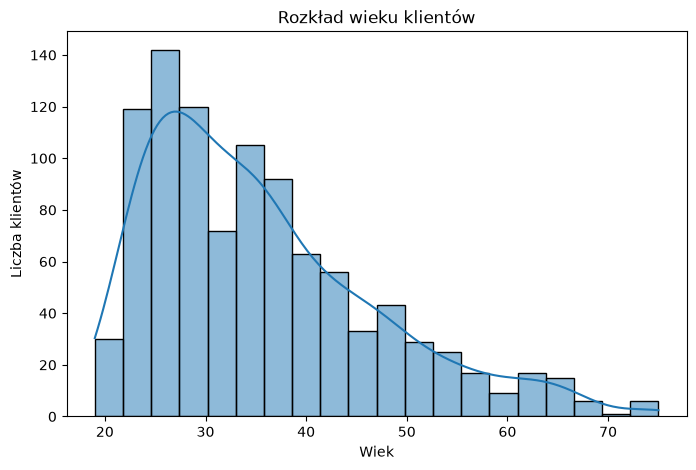

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='wiek', bins=20, kde=True)
plt.title('Rozkład wieku klientów')
plt.xlabel('Wiek')
plt.ylabel('Liczba klientów')
plt.show()

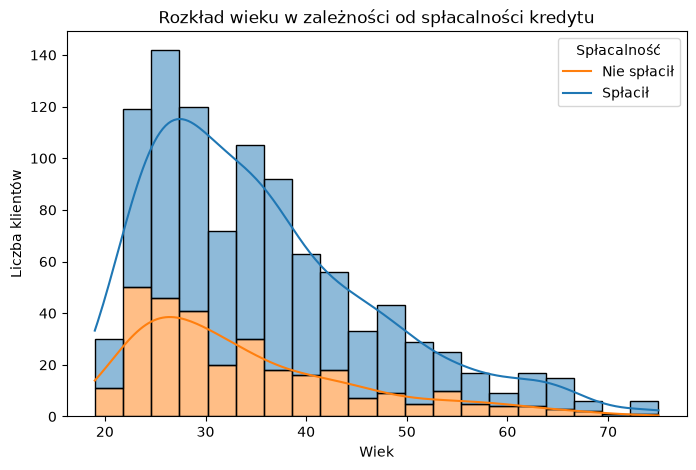

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='wiek', hue='target', bins=20, kde=True, multiple='stack')
plt.title('Rozkład wieku w zależności od spłacalności kredytu')
plt.xlabel('Wiek')
plt.ylabel('Liczba klientów')
plt.legend(title='Spłacalność', labels=['Nie spłacił', 'Spłacił'])
plt.show()

## Podsumowanie EDA
- Dataset: 1000 wierszy, 21 kolumn (20 cech + target)
- Brak brakujących danych i duplikatów
- Target niezbalansowany: 70% spłaciło, 30% nie spłaciło -> uwzględnić przy modelowaniu (class_weight/SMOTE)
- 13 kolumn kategorycznych wymaga zakodowania przed modelowaniem
- Klienci którzy nie spłacili są średnio nieco młodsi